<a href="https://colab.research.google.com/github/mducdaf2/ai-knowledges/blob/main/KAN/B_splines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# B spline

## 1. Polynomial Interpolation

Nội suy đa thức (polynomial interpolation) là quá trình tìm kiếm các hệ số (coefficients) của một hàm đa thức: $P(x) = a_0 + a_1x + ... + a_n x^n$ đi qua các điểm dữ liệu cho trước.

Ví dụ, với 4 điểm dữ liệu $[(x_1, y_1), (x_2, y_2), (x_3, y_3), (x_4, y_4)]$, chúng ta có thể tìm được đa thức bậc 3 (cubic polynomial) $a_0 + a_1x + a_2x^2 + a_3x^3$ bằng việc giải hệ phương trình:
$$ \begin{pmatrix}
1 & x_1 & x_1^2 & x_1^3 \\
1 & x_2 & x_2^2 & x_2^3 \\
1 & x_3 & x_3^2 & x_3^3 \\
1 & x_4 & x_4^2 & x_4^3
\end{pmatrix}
\begin{pmatrix}
a_0 \\
a_1 \\
a_2 \\
a_3
\end{pmatrix}
=
\begin{pmatrix}
y_1 \\
y_2 \\
y_3 \\
y_4
\end{pmatrix} $$

[[0]
 [1]
 [2]
 [3]]
[[1. ]
 [1.5]
 [5. ]
 [1. ]]


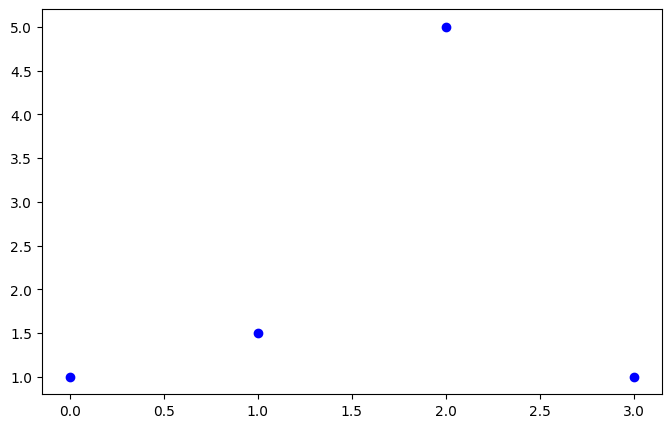

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# Khởi tạo 4 điểm dữ liệu
x = np.array([0, 1, 2, 3]).reshape(4, 1)
y = np.array([1.0, 1.5, 5.0, 1.0]).reshape(4, 1)
print(x)
print(y)

plt.figure(figsize=(8, 5))
plt.plot(x, y, 'bo')
plt.show()

In [18]:
# Khởi tạo ma trận Vandemore
A = np.concat([x**0, x, x**2, x**3], axis=1)
print(A)

# Giải hệ phương trình tìm hệ số:
coeff = np.linalg.solve(A, y)
print("Hệ số của phương trình cubic:", coeff.reshape(4, ))

[[ 1  0  0  0]
 [ 1  1  1  1]
 [ 1  2  4  8]
 [ 1  3  9 27]]
Hệ số của phương trình cubic: [ 1.   -4.5   6.75 -1.75]


(100, 4)
(100, 1)


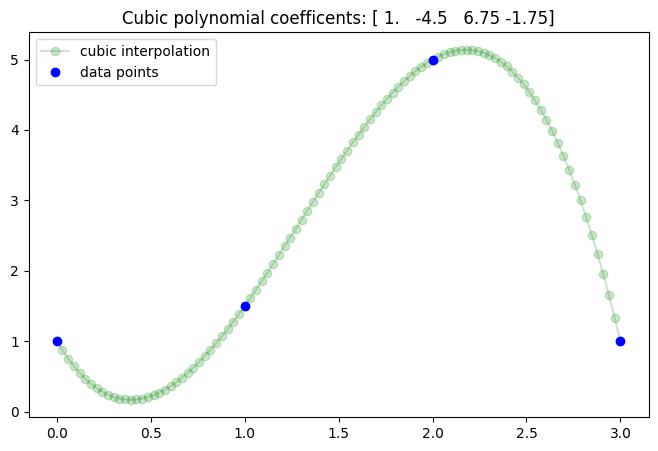

In [60]:
# Trực quan hoá
x_temp = np.linspace(0, 3, 100).reshape(-1, 1)
x_vandermore = np.concat([x_temp**i for i in range(4)], axis=1)
print(x_vandermore.shape)
y_temp = x_vandermore @ coeff
print(y_temp.shape)

plt.figure(figsize=(8, 5))
plt.plot(x_temp, y_temp, 'g-o', alpha=0.2, label="cubic interpolation")
plt.plot(x, y, 'bo', label="data points")
plt.title(f"Cubic polynomial coefficents: {coeff.reshape(4, )}")
plt.legend()
plt.show()

Lưu ý:
- Đa thức bậc $n$ cần đúng $n+1$ điểm phân biệt để xác định nghiệm duy nhất.
- Đa thức bậc cao hơn dẫn đến có nhiều nghiệm thoả mãn hơn, và đa thức bậc thấp hơn có thể sẽ không tồn tại nghiệm.

Trên thực tế, rất khó để đảm bảo sẽ tìm được nghiệm phù hợp của những đa thức bậc cao, nếu được cũng yêu cầu rất nhiều tài nguyên tính toán. Một ý tưởng cơ bản, chúng ta sẽ tách nhỏ đồ thị của đa thức bậc cao thành các phần nhỏ, và các phần nhỏ đó được xấp xỉ bởi một đa thức có bậc nhỏ hơn nhiều, đó là ý tưởng của việc sử dụng spline cho phép nội suy (interpolation).

## 2. Splines
Splines được hiểu là sự kết hợp của nhiều đa thức bậc thấp hơn (lower-order polynomial) để tạo thành những đường cong phức tạp hơn (complex) và mượt hơn (smooth).

Những đường cong bậc thấp hơn thường sử dụng đa thức bậc 3 vì sự cân bằng giữa khả năng biểu diễn (expressivity) và độ phức tạp (complexity).

Có nhiều loại splines, được chia dựa trên cách mà các đa thức nhỏ kết nối lại với nhau, tạo nên sự mượt cho đường cong chính. Và có 2 trường phải chính có thể đề cập tới:
- Iterpolating: Đi qua toàn bộ data points, hay còn gọi là control points.
- Approximating: Không nhất nhiết phải đi qua toàn bộ data points, cân bằng giữa sự mượt mà và độ khớp chính xác.

![](https://rohangautam.github.io/img/quv4FAWSDe-1200.avif)

Một số thuật ngữ:
- Các điểm **control points** sẽ quyết định hình dạng của spline.
- Các phần đường cong đa thức nhỏ được nối với nhau tại các điểm gọi là **knots**, các điểm này sẽ quy định các spline chia nhỏ thành các phần đa thức. Nhiều loại spline sẽ chọn knots chính tại các control points, nhưng nhiều loại xây dựng knots riêng để phù hợp với mục tiêu bài toán.

### 2.1. Continuity
Liên tục (đôi khi được gọi là độ mượt - *smoothness*) là thang đo sự trơn tru của các hàm polynomial khi nối với nhau.

Một ví dụ đơn giản, là sự thay đổi liên tục của vận tốc, đây là một trường hợp của **continuity** $C^1$, khi đó ta có đạo hàm cấp một liên tục tại các phần giao (join).
![](https://rohangautam.github.io/img/Q5F3D5rzOd-1200.avif)

Một cách tổng quát, $C^n$ continuity có nghĩa rằng đạo hàm cấp $n^{th}$ liên tục tại các phần join và cũng đồng nghĩa với việc các đạo hàm thấp hơn ($(n-1, ..., 0)^{th}$) cũng tồn tại và liên tục. Với giá trị $n$ càng cao, sẽ cung cấp cho ta một đường cong càng mượt (smooth).

### 2.2. Basis function
Ở phần trên, có đề cập tới việc hình dáng của đường cong được xác định bởi các control point, nhưng chưa hình dung được sẽ xác định như thế nào. Một cách hiệu quả là sử dụng basis function.

Basis function giúp xác định mức độ ảnh hưởng (influence) mà các control point tác động vào curve.
![](https://rohangautam.github.io/img/KE95lES_aD-1200.gif)

## 3. B-splines
B-spline thuộc loại $C^2$ continous và có chức năng điều khiển cục bộ (local control). Các điểm control point để xác định spline không cần phải cách đều nhau, mang lại sự linh hoạt cho các trường hợp thực tế.

## References
- Nội dung lấy ý tưởng từ: https://rohangautam.github.io/blog/b_spline_intro/
- Tutorial tham khảo: https://github.com/pg2455/KAN-Tutorial
- Lý thuyết về B-spline: https://www.uio.no/studier/emner/matnat/math/MAT4170/v25/undervisningsmateriale/spline_notes.pdf
- Giải thích các công thức trong KAN: https://alexzhang13.github.io/blog/2024/annotated-kan/
- Codebase pykan: https://alexzhang13.github.io/blog/2024/annotated-kan/